# Time Series 

This script runs time-based visuals and modeling on the payment_date within the general_payments_record_id_level_clean.csv. It provides counts and amounts by year, by nature of payment, by quarter. It shows anomalies by quarter and anomalies in billing spikes specified by rolling quarterly amounts for individual PIs as well. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True

In [2]:
# load data
df = pd.read_csv("../SpIn_2_Artifacts/general_payments_record_id_level_clean.csv")

In [3]:
df.columns

Index(['Unnamed: 0', 'Unnamed: 0.1', 'record_id', 'change_type',
       'payment_publication_date', 'date_of_payment', 'program_year',
       'covered_recipient_npi',
       'applicable_manufacturer_or_applicable_gpo_making_payment_id',
       'total_amount_of_payment_us_dollars',
       'number_of_payments_included_in_total_amount',
       'form_of_payment_or_transfer_of_value',
       'nature_of_payment_or_transfer_of_value', 'nature_short_descr',
       'city_of_travel', 'state_of_travel', 'country_of_travel',
       'physician_ownership_indicator',
       'third_party_payment_recipient_indicator',
       'name_of_third_party_entity_receiving_payment_or_transfer_of_value',
       'charity_indicator', 'third_party_equals_covered_recipient_indicator',
       'dispute_status_for_publication', 'covered_biological',
       'covered_device', 'covered_drug', 'covered_medical supply',
       'non-covered_device', 'non-covered_drug', 'non-covered_medical supply'],
      dtype='object')

In [4]:
df.drop(columns = ['Unnamed: 0', 'Unnamed: 0.1'], inplace = True)

In [5]:
# Ensure column names match your dataset
# Adjust if yours are different
expected_cols = ["date_of_payment", "covered_recipient_npi", "total_amount_of_payment_us_dollars"]
print("Columns in df:", df.columns.tolist())

# Convert transaction_date to datetime
df["date_of_payment"] = pd.to_datetime(df["date_of_payment"])

# Sort by date
df = df.sort_values("date_of_payment")

# Optional: optimize dtypes for performance (6M rows)
df["covered_recipient_npi"] = df["covered_recipient_npi"].astype("Int64")

# Set date as index for easy resampling
df = df.set_index("date_of_payment")

df.info()


Columns in df: ['record_id', 'change_type', 'payment_publication_date', 'date_of_payment', 'program_year', 'covered_recipient_npi', 'applicable_manufacturer_or_applicable_gpo_making_payment_id', 'total_amount_of_payment_us_dollars', 'number_of_payments_included_in_total_amount', 'form_of_payment_or_transfer_of_value', 'nature_of_payment_or_transfer_of_value', 'nature_short_descr', 'city_of_travel', 'state_of_travel', 'country_of_travel', 'physician_ownership_indicator', 'third_party_payment_recipient_indicator', 'name_of_third_party_entity_receiving_payment_or_transfer_of_value', 'charity_indicator', 'third_party_equals_covered_recipient_indicator', 'dispute_status_for_publication', 'covered_biological', 'covered_device', 'covered_drug', 'covered_medical supply', 'non-covered_device', 'non-covered_drug', 'non-covered_medical supply']
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6467206 entries, 2021-01-01 to 2023-12-31
Data columns (total 27 columns):
record_id                 

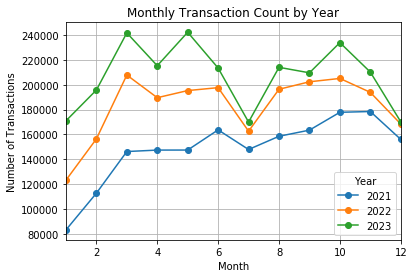

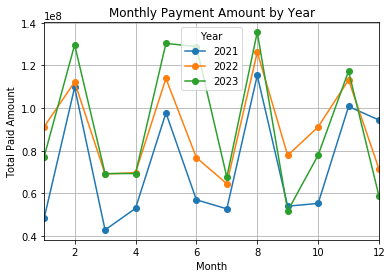

In [6]:
# Year-level time series (monthly by year)

# Add year and month columns (derived from index)
df["year"] = df.index.year
df["month"] = df.index.month

# Monthly transaction count
monthly_counts = (
    df
    .resample("M")  # monthly by calendar month
    .size()
    .to_frame("txn_count")
)
monthly_counts["year"] = monthly_counts.index.year
monthly_counts["month"] = monthly_counts.index.month

# Pivot to have one line per year
monthly_counts_pivot = monthly_counts.pivot(index="month", columns="year", values="txn_count")

# Plot: monthly counts by year
ax = monthly_counts_pivot.plot(marker="o")
ax.set_title("Monthly Transaction Count by Year")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Transactions")
plt.legend(title="Year")
plt.show()


# Monthly total payment amount
monthly_amounts = (
    df
    .resample("M")["total_amount_of_payment_us_dollars"]
    .sum()
    .to_frame("total_amount")
)
monthly_amounts["year"] = monthly_amounts.index.year
monthly_amounts["month"] = monthly_amounts.index.month

monthly_amounts_pivot = monthly_amounts.pivot(index="month", columns="year", values="total_amount")

ax = monthly_amounts_pivot.plot(marker="o")
ax.set_title("Monthly Payment Amount by Year")
ax.set_xlabel("Month")
ax.set_ylabel("Total Paid Amount")
plt.legend(title="Year")
plt.show()


Top 15 nature_short_descr by total amount:


,txn_count,total_amount,avg_amount
nature_short_descr,,,
Consulting,184376,5.399852e+08,2928.717535
Food and Beverage,5386265,2.454992e+08,45.578738
Other Services,91445,2.131920e+08,2331.368312
Acquisition,1259,1.874709e+08,148904.568546
Education,98149,1.225242e+08,1248.349351
Faculty or Speaker,16344,4.646548e+07,2842.968748
Ownership or Investment,148,7.863910e+06,53134.526284
Debt Forgiveness,3005,5.448914e+06,1813.282493
Entertainment,4654,4.155769e+05,89.294568


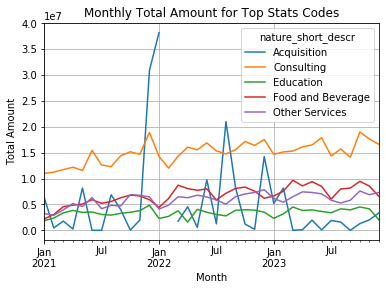

In [7]:
# Stats code level summary & trends

# Overall summary by stats_code
stats_summary = (
    df
    .groupby("nature_short_descr")
    .agg(
        txn_count=("total_amount_of_payment_us_dollars", "size"),
        total_amount=("total_amount_of_payment_us_dollars", "sum"),
        avg_amount=("total_amount_of_payment_us_dollars", "mean")
    )
    .sort_values("total_amount", ascending=False)
)

print("Top 15 nature_short_descr by total amount:")
display(stats_summary.head(15))

# Time series: monthly total per stats_code for top codes
top_codes = stats_summary.head(5).index.tolist()

monthly_by_code = (
    df[df["nature_short_descr"].isin(top_codes)]
    .groupby(["nature_short_descr", pd.Grouper(freq="M")])["total_amount_of_payment_us_dollars"]
    .sum()
    .reset_index()
    .rename(columns={"date_of_payment": "month"})
)

# Pivot for plotting
monthly_by_code_pivot = monthly_by_code.pivot(
    index="month",
    columns="nature_short_descr",
    values="total_amount_of_payment_us_dollars"
)

ax = monthly_by_code_pivot.plot()
ax.set_title("Monthly Total Amount for Top Stats Codes")
ax.set_xlabel("Month")
ax.set_ylabel("Total Amount")
plt.legend(title="nature_short_descr")
plt.show()


In [8]:
df.columns

Index(['record_id', 'change_type', 'payment_publication_date', 'program_year',
       'covered_recipient_npi',
       'applicable_manufacturer_or_applicable_gpo_making_payment_id',
       'total_amount_of_payment_us_dollars',
       'number_of_payments_included_in_total_amount',
       'form_of_payment_or_transfer_of_value',
       'nature_of_payment_or_transfer_of_value', 'nature_short_descr',
       'city_of_travel', 'state_of_travel', 'country_of_travel',
       'physician_ownership_indicator',
       'third_party_payment_recipient_indicator',
       'name_of_third_party_entity_receiving_payment_or_transfer_of_value',
       'charity_indicator', 'third_party_equals_covered_recipient_indicator',
       'dispute_status_for_publication', 'covered_biological',
       'covered_device', 'covered_drug', 'covered_medical supply',
       'non-covered_device', 'non-covered_drug', 'non-covered_medical supply',
       'year', 'month'],
      dtype='object')

In [9]:
# Quarterly NPI-level series & spike detection

# Aggregate to quarterly totals per NPI
quarterly_npi = (
    df
    .groupby(
        [
            "covered_recipient_npi",
            pd.Grouper(freq="Q") # quarterly
        ]
    )["total_amount_of_payment_us_dollars"]
    .sum()
    .reset_index()
    .rename(
        columns={
            "date_of_payment": "quarter",
            "total_amount_of_payment_us_dollars": "quarterly_amount"
        }
    )
)

quarterly_npi = quarterly_npi.sort_values(["covered_recipient_npi", "quarter"])

In [10]:
quarterly_npi.head(4)

,covered_recipient_npi,quarter,quarterly_amount
0,1003000142,2021-03-31,84.44
1,1003000142,2021-06-30,667.64
2,1003000142,2021-09-30,1092.29
3,1003000142,2021-12-31,436.75


In [14]:
quarter_counts = quarterly_npi.groupby("covered_recipient_npi")["quarter"].nunique()
mask = quarterly_npi["covered_recipient_npi"].map(quarter_counts) > 4
quarterly_npi_4plus = quarterly_npi[mask].copy()

In [16]:
# Rolling stats and z-score per NPI (e.g., 4-quarter rolling window ~ 1 year)
window = 4  # 4 quarters

quarterly_npi_4plus["rolling_mean"] = (
    quarterly_npi_4plus
    .groupby("covered_recipient_npi")["quarterly_amount"]
    .transform(lambda s: s.rolling(window, min_periods=2).mean())
)

quarterly_npi_4plus["rolling_std"] = (
    quarterly_npi_4plus
    .groupby("covered_recipient_npi")["quarterly_amount"]
    .transform(lambda s: s.rolling(window, min_periods=2).std())
)

# Avoid divide-by-zero
quarterly_npi_4plus["rolling_std"] = quarterly_npi_4plus["rolling_std"].replace(0, np.nan)

quarterly_npi_4plus["z_score"] = (
    (quarterly_npi_4plus["quarterly_amount"] - quarterly_npi_4plus["rolling_mean"]) /
    quarterly_npi_4plus["rolling_std"]
)

# Define spike threshold
z_threshold = 1.0

quarterly_npi_4plus["is_spike"] = quarterly_npi_4plus["z_score"] > z_threshold

# Quick sanity check: how many spikes & NPIs
spike_summary = (
    quarterly_npi_4plus[quarterly_npi_4plus["is_spike"]]
    .groupby("covered_recipient_npi")
    .agg(
        spike_quarters=("quarter", "nunique"),
        max_z=("z_score", "max")
    )
    .sort_values("spike_quarters", ascending=False)
)

print("Top NPIs by number of spike quarters:")
display(spike_summary.head(10))

Top NPIs by number of spike quarters:


,spike_quarters,max_z
covered_recipient_npi,,
1417155821,8,1.466267
1568660165,8,1.414745
1114926565,7,1.499202
1013371442,7,1.411387
1801811096,7,1.401511
1851416606,7,1.335833
1457585903,7,1.384150
1891877742,6,1.474859
1053426643,6,1.491388


In [48]:
def plot_npi_quarterly_spikes(quarterly_npi_df, npi_id, ax=None):
    """
    Plot quarterly total amount for a given NPI and highlight spike quarters.
    If ax is provided, plot on that axis; otherwise create a new figure.
    """
    subset = quarterly_npi_df[quarterly_npi_df["covered_recipient_npi"] == npi_id].copy()

    if subset.empty:
        if ax is None:
            print(f"No data for NPI {npi_id}")
        else:
            ax.set_title(f"NPI {npi_id}\n(no data)")
            ax.axis("off")
        return
    
    subset = subset.sort_values("quarter")

    # Create axis if not passed in
    if ax is None:
        fig, ax = plt.subplots()

    ax.plot(subset["quarter"], subset["quarterly_amount"], label="Quarterly Amount")

    if "is_spike" in subset.columns:
        spikes = subset[subset["is_spike"]]
        if not spikes.empty:
            ax.scatter(spikes["quarter"], spikes["quarterly_amount"], s=60, marker="o", label="Spikes")

    ax.set_xlabel("Quarter")
    ax.set_ylabel("Quarterly Total Amount")
    ax.tick_params(axis="x", labelrotation=45)
    ax.legend()

    if ax is None:
        plt.tight_layout()
        plt.show()

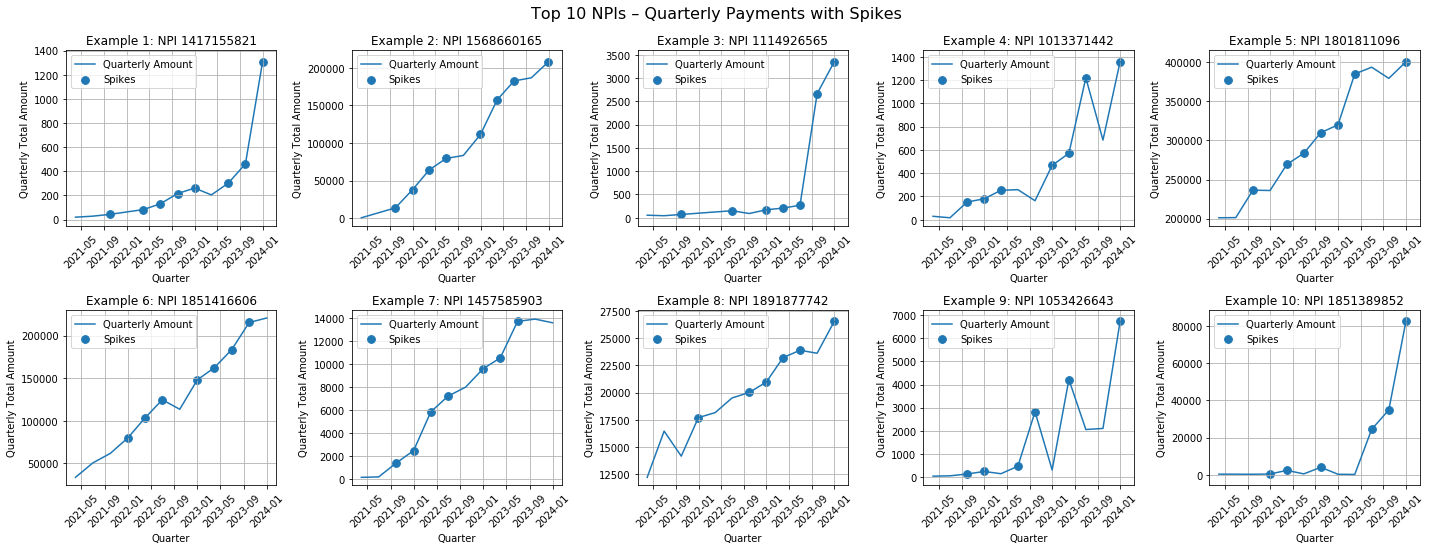

In [50]:
# Top 10 NPIs by number of spike quarters
top_npis = spike_summary.head(10).index

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, (ax, npi_id) in enumerate(zip(axes, top_npis), start=1):
    plot_npi_quarterly_spikes(quarterly_npi_4plus, npi_id, ax=ax)
    ax.set_title(f"Example {i}: NPI {npi_id}")

# If fewer than 10 NPIs, hide extra axes
for j in range(len(top_npis), len(axes)):
    axes[j].axis("off")

fig.suptitle("Top 10 NPIs – Quarterly Payments with Spikes", fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [57]:
# Top 10 NPIs where spike quarters = 1
spike1_npis = spike_summary[spike_summary["spike_quarters"] == 6].head(10)
spike1_npis

,spike_quarters,max_z
covered_recipient_npi,,
1891877742,6,1.474859
1053426643,6,1.491388
1851389852,6,1.498165
1255317194,6,1.330900
1891147773,6,1.497287
1619149119,6,1.487370
1124113667,6,1.369689
1467651919,6,1.475068
1023049558,6,1.404351


In [65]:
# Simple insight snippets

# Year-over-year total amount change
yearly_amounts = (
    df
    .groupby("year")["total_amount_of_payment_us_dollars"]
    .sum()
    .sort_index()
)

print("Total amount by year:")
display(df["total_amount_of_payment_us_dollars"].sum())

print("Total amount:")
display(yearly_amounts.to_frame("total_amount_of_payment_us_dollars"))

yearly_growth = yearly_amounts.pct_change() * 100
print("\nYear-over-year % change in total amount:")
display(yearly_growth.to_frame("pct_change"))

# Identify top NPIs by total amount
npi_summary = (
    df
    .groupby("covered_recipient_npi")["total_amount_of_payment_us_dollars"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count": "txn_count", "sum": "total_amount", "mean": "avg_amount"})
    .sort_values("total_amount", ascending=False)
)

print("\nTop 15 NPIs by total amount:")
display(npi_summary.head(15))

# For each top NPI, how many spike days?
top_npis = npi_summary.head(15).index
top_npi_spikes = spike_summary.loc[spike_summary.index.intersection(top_npis)]

print("\nSpike behavior in top 15 NPIs:")
display(top_npi_spikes)


Total amount by year:


3072828927.129999

Total amount:


,total_amount_of_payment_us_dollars
year,
2021,8.814853e+08
2022,1.077489e+09
2023,1.113855e+09



Year-over-year % change in total amount:


,pct_change
year,
2021,NaN
2022,22.235591
2023,3.375085



Top 15 NPIs by total amount:


,txn_count,total_amount,avg_amount
covered_recipient_npi,,,
1366487498,12,95451652.72,7.954304e+06
1861451874,130,56094047.03,4.314927e+05
1336247469,12,43366542.57,3.613879e+06
1295737930,20,33852863.72,1.692643e+06
1326242116,7,26509302.24,3.787043e+06
1669457354,25,23151361.26,9.260545e+05
1811044548,58,22318074.80,3.847944e+05
1528006731,181,20626994.52,1.139613e+05
1639290562,54,14967756.19,2.771807e+05



Spike behavior in top 15 NPIs:


,spike_quarters,max_z
covered_recipient_npi,,
1639290562,4,1.500000
1528006731,3,1.499954
1336247469,3,1.408830
1780680074,3,1.193828
1366487498,2,1.346717
1356459093,2,1.499999
1811044548,2,1.497940
1669457354,2,1.206243
1932140266,2,1.498207


In [38]:
# Aggregate to quarterly totals (you can also use mean/count depending on use case)
ts_q = df["total_amount_of_payment_us_dollars"].resample("Q").sum()

print(ts_q.head())

date_of_payment
2021-03-31    2.011254e+08
2021-06-30    2.077515e+08
2021-09-30    2.221036e+08
2021-12-31    2.505048e+08
2022-03-31    2.726347e+08
Freq: Q-DEC, Name: total_amount_of_payment_us_dollars, dtype: float64


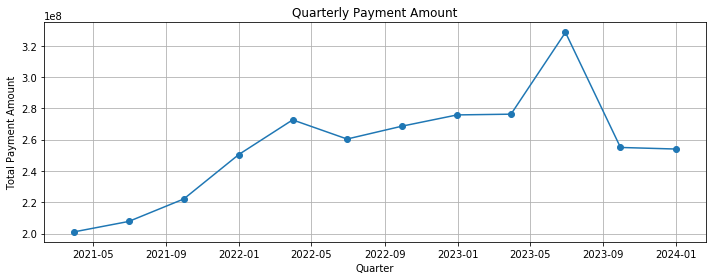

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(ts_q, marker="o")
plt.title("Quarterly Payment Amount")
plt.xlabel("Quarter")
plt.ylabel("Total Payment Amount")
plt.tight_layout()
plt.show()


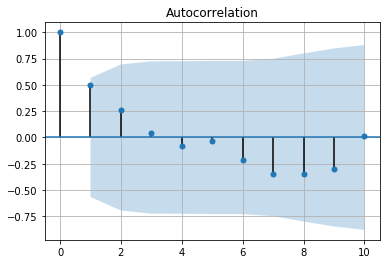

/opt/conda/lib/python3.7/site-packages/statsmodels/regression/linear_model.py:1283: RuntimeWarning: invalid value encountered in sqrt
  return rho, np.sqrt(sigmasq)


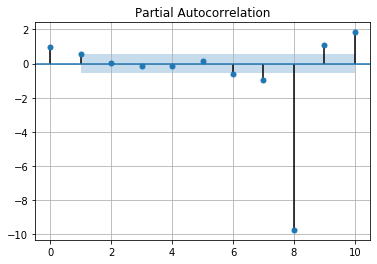

In [41]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(ts_q, lags=10)
plt.show()

plot_pacf(ts_q, lags=10)
plt.show()

In [42]:
from statsmodels.tsa.seasonal import seasonal_decompose

# period=4 because quarterly data (4 quarters per year)
decomp = seasonal_decompose(ts_q, model="additive", period=4)

fig = decomp.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()

# You now have:
trend = decomp.trend
seasonal = decomp.seasonal
resid = decomp.resid

TypeError: seasonal_decompose() got an unexpected keyword argument 'period'

In [59]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts_q.dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])

# Simple differencing if needed
ts_q_diff = ts_q.diff().dropna()          # first difference (non-seasonal)
ts_q_seasonal_diff = ts_q.diff(4).dropna()  # seasonal difference with period=4

ADF Statistic: -2.3459528934058875
p-value: 0.1575750840143021


Anomalous quarters:
 date_of_payment
2023-06-30    3.285350e+08
Freq: Q-DEC, Name: total_amount_of_payment_us_dollars, dtype: float64


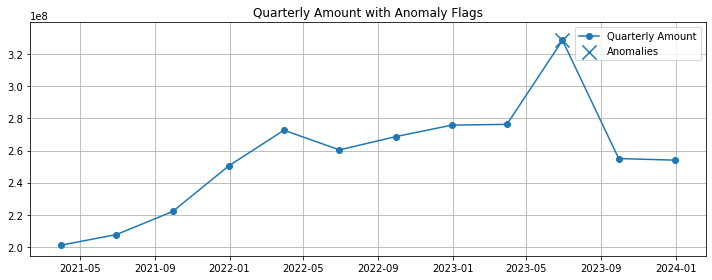

In [63]:
window = 4  # one year of quarters
rolling_mean = ts_q.rolling(window=window, center=True).mean()
rolling_std = ts_q.rolling(window=window, center=True).std()

z_scores = (ts_q - rolling_mean) / rolling_std

# Flag quarters with |z| > 31 as anomalies
anomalies = ts_q[abs(z_scores) > 1]
print("Anomalous quarters:\n", anomalies)

plt.figure(figsize=(10, 4))
plt.plot(ts_q, label="Quarterly Amount", marker="o")
plt.scatter(anomalies.index, anomalies.values, marker="x", s=200, label="Anomalies")
plt.legend()
plt.title("Quarterly Amount with Anomaly Flags")
plt.tight_layout()
plt.show()